# Week 8: Deal Agents & Modal Deployment – Wakanda Chimobi Ogudu

Deploy the Week 7 fine-tuned pricer to Modal (us-east). **Scanner** (RSS bargains), **Ensemble** (Specialist + Frontier+RAG + Neural), **Messaging** (push + LLM draft), **Planning** (orchestrator). Custom framework: memory + logging. Gradio UI. No Langchain.

In [1]:
import sys
!{sys.executable} -m pip install -q modal feedparser requests beautifulsoup4 chromadb sentence-transformers litellm python-dotenv gradio pandas matplotlib scikit-learn

In [2]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(override=True)

work = Path.cwd()
if str(work) not in sys.path:
    sys.path.insert(0, str(work))
print("Working dir:", work)

Working dir: c:\Users\DELL\Documents\ed-projects\llm_engineering\week8\community_contributions\Wakanda-Chimobi-Ogudu-Week-8


In [4]:
import chromadb
from sentence_transformers import SentenceTransformer

DB_PATH = "products_vectorstore"
COLLECTION_NAME = "products"

def get_or_build_collection():
    client = chromadb.PersistentClient(path=DB_PATH)
    coll = client.get_or_create_collection(COLLECTION_NAME, metadata={"description": "Product descriptions for RAG"})
    try:
        if coll.count() == 0:
            model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")            
            samples = [
                ("LG 55\" 4K UHD Roku Smart TV", "Electronics", 348.0),
                ("Poly Studio P21 21.5\" LED meeting display", "Computers", 199.0),
                ("Lenovo IdeaPad Slim 5 16\" Ryzen 5 laptop", "Computers", 549.0),
                ("Dell G15 Ryzen 5 15.6\" Gaming Laptop RTX 3050", "Computers", 699.0),
                ("Parrot Anker Solix C1000 1800W Portable Power Station", "Electronics", 45.0),
                ("RTX 3050", "Computers", 89.0),
                ("27\" IPS monitor 144Hz", "Electronics", 279.0),
            ]
            docs = [f"Title: {t}\nCategory: {c}" for t, c, _ in samples]
            ids = [f"id_{i}" for i in range(len(docs))]
            metas = [{"price": p} for _, _, p in samples]
            emb = model.encode(docs)
            coll.add(ids=ids, documents=docs, embeddings=emb.tolist(), metadatas=metas)
            print("Added", len(docs), "sample products to RAG store")
        else:
            print("RAG collection already has", coll.count(), "documents")
    except Exception as e:
        print("RAG build warning:", e)
    return coll

collection = get_or_build_collection()

RAG collection already has 7 documents


In [ ]:
# Deploy: run in terminal from this folder:
#   cd week8/community_contributions/Wakanda-Chimobi-Ogudu-Week-8
#   modal deploy modal_services/specialist_pricer.py
# Region is us-east (close to New York). No Langchain.
# After deploy, SpecialistAgent in agents.py will call Modal automatically.
print("Deploy with: python -m modal deploy modal_services/specialist_pricer.py")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
TEST_ITEMS = [
    ("Hisense R6 55\" 4K UHD Roku Smart TV Dolby Vision", 348.0),
    ("Poly Studio P21 21.5\" LED meeting display 1080p", 199.0),
    ("Lenovo IdeaPad Slim 5 16\" Ryzen 5 8645HS 16GB 512GB", 549.0),
    ("Dell G15 Ryzen 5 7640HS 15.6\" 120Hz 16GB 1TB RTX 3050", 699.0),
    ("Wireless Bluetooth over-ear headphones 30h battery", 45.0),
    ("Mechanical keyboard RGB backlit brown switch", 89.0),
]

def parse_price(s):
    if s is None: return 0.0
    import re
    s = str(s).replace("$", "").replace(",", "")
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return max(0.0, float(m.group())) if m else 0.0

def run_predictor(predictor, items, name):
    actuals, preds = [], []
    for desc, price in items:
        actuals.append(price)
        out = predictor(desc)
        preds.append(out if isinstance(out, (int, float)) else parse_price(out))
    actuals, preds = np.array(actuals), np.array(preds)
    mae = np.mean(np.abs(actuals - preds))
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    r2 = r2_score(actuals, preds)
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "actuals": actuals, "preds": preds}

In [6]:
from agents import FrontierAgent, NeuralNetworkAgent, EnsembleAgent, SpecialistAgent

mean_price = np.mean([p for _, p in TEST_ITEMS])
baseline = run_predictor(lambda d: mean_price, TEST_ITEMS, "Baseline (mean)")
frontier_agent = FrontierAgent(collection)
frontier = run_predictor(frontier_agent.price, TEST_ITEMS, "Frontier + RAG")
neural_agent = NeuralNetworkAgent()
neural = run_predictor(neural_agent.price, TEST_ITEMS, "Neural net")
ensemble_agent = EnsembleAgent(collection=collection)
ensemble = run_predictor(ensemble_agent.price, TEST_ITEMS, "Ensemble")
try:
    spec_agent = SpecialistAgent()
    specialist = run_predictor(spec_agent.price, TEST_ITEMS, "Specialist (fine-tuned)")
except Exception as e:
    specialist = {"name": "Specialist (fine-tuned)", "mae": np.nan, "rmse": np.nan, "r2": np.nan, "actuals": baseline["actuals"], "preds": baseline["preds"]}
    print("Specialist (Modal) skipped:", e)

In [7]:
rows = [baseline, frontier, neural, ensemble, specialist]
comparison_df = pd.DataFrame([{"Model": r["name"], "MAE": r["mae"], "RMSE": r["rmse"], "R²": r["r2"]} for r in rows])
print(comparison_df.to_string(index=False))

                  Model        MAE       RMSE        R²
        Baseline (mean) 210.500000 238.215414  0.000000
         Frontier + RAG   5.833333  10.992422  0.997871
             Neural net 273.166667 361.190854 -1.298972
               Ensemble  44.160667  46.721641  0.961532
Specialist (fine-tuned)  88.333333  94.043537  0.844146


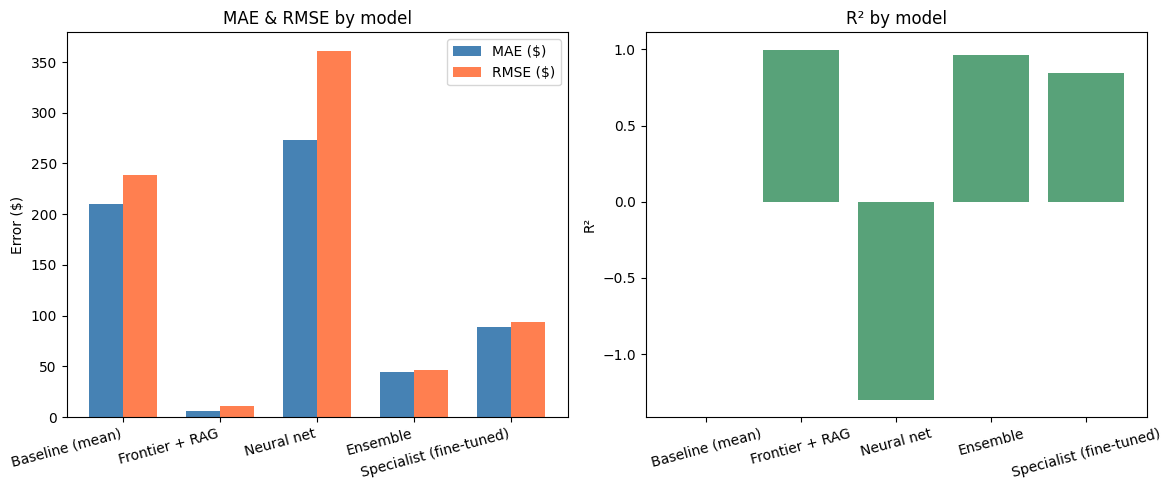

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axes[0], axes[1]
models = [r["name"] for r in rows]
mae_vals = [r["mae"] for r in rows]
rmse_vals = [r["rmse"] for r in rows]
x = np.arange(len(models))
w = 0.35
ax1.bar(x - w/2, mae_vals, w, label="MAE ($)", color="steelblue")
ax1.bar(x + w/2, rmse_vals, w, label="RMSE ($)", color="coral")
ax1.set_ylabel("Error ($)")
ax1.set_title("MAE & RMSE by model")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha="right")
ax1.legend()
r2_vals = [np.nan_to_num(r["r2"], nan=0.0) for r in rows]
ax2.bar(models, r2_vals, color="seagreen", alpha=0.8)
ax2.set_ylabel("R²")
ax2.set_title("R² by model")
ax2.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [9]:
from agent_framework import DealMemory, init_logging
from agents import PlanningAgent, EnsembleAgent, Deal

_last_opportunity = None
_comparison_table = None

def set_comparison_table(df):
    global _comparison_table
    _comparison_table = df

def run_plan_once():
    init_logging()
    memory = DealMemory()
    planner = PlanningAgent(collection=collection, memory=memory, deal_threshold=3.0)
    opp = planner.plan()
    global _last_opportunity
    _last_opportunity = opp
    if opp:
        return f"Best deal: {opp.deal.product_description[:150]}... | Price ${opp.deal.price:.2f} | Est ${opp.estimate:.2f} | Discount ${opp.discount:.2f}"
    return "No new deal above threshold this run."

def estimate_price(description):
    if not description or not description.strip():
        return "Enter a product description."
    ens = EnsembleAgent(collection=collection)
    est = ens.price(description.strip())
    return f"Estimated price: ${est:.2f}"

In [ ]:
import gradio as gr

set_comparison_table(comparison_df)

with gr.Blocks(title="Deal Agents – Week 8") as demo:
    gr.Markdown("## Deal Agents: Scanner, Ensemble, Messaging, Planning")
    with gr.Tab("Run planning"):
        run_btn = gr.Button("Run planning agent (scan RSS → ensemble → notify)")
        plan_out = gr.Textbox(label="Result", lines=4)
        run_btn.click(fn=run_plan_once, outputs=plan_out)
    with gr.Tab("Estimate price"):
        desc_in = gr.Textbox(label="Product description", placeholder="e.g. 55\" 4K Smart TV")
        price_btn = gr.Button("Estimate price")
        price_out = gr.Textbox(label="Ensemble estimate")
        price_btn.click(fn=estimate_price, inputs=desc_in, outputs=price_out)
    with gr.Tab("Model comparison"):
        gr.Markdown("Performance (MAE, RMSE, R²) across models")
        gr.Dataframe(value=comparison_df, interactive=False)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://de034efcf67f68a939.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


19:45:58 - LiteLLM:INFO: utils.py:3421 - 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
[2026-03-11 19:45:58] [LiteLLM] [INFO] 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
19:46:06 - LiteLLM:INFO: utils.py:1302 - Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:06] [LiteLLM] [INFO] Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:31] [agent.Specialist] [INFO] Specialist estimate {'value': 17.0}
[2026-03-11 19:46:31] [sentence_transformers.SentenceTransformer] [INFO] Use pytorch device_name: cpu
[2026-03-11 19:46:31] [sentence_transformers.SentenceTransformer] [INFO] Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

19:46:36 - LiteLLM:INFO: utils.py:3421 - 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
[2026-03-11 19:46:36] [LiteLLM] [INFO] 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
19:46:37 - LiteLLM:INFO: utils.py:1302 - Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:37] [LiteLLM] [INFO] Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:37] [agent.Ensemble] [INFO] Ensemble {'specialist': 17.0, 'frontier': 17.0, 'neural': 50.0, 'combined': 21.95}
[2026-03-11 19:46:38] [agent.Specialist] [INFO] Specialist estimate {'value': 355.0}


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

19:46:40 - LiteLLM:INFO: utils.py:3421 - 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
[2026-03-11 19:46:40] [LiteLLM] [INFO] 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
19:46:41 - LiteLLM:INFO: utils.py:1302 - Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:41] [LiteLLM] [INFO] Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:41] [agent.Ensemble] [INFO] Ensemble {'specialist': 27.0, 'frontier': 27.0, 'neural': 50.0, 'combined': 30.45}
[2026-03-11 19:46:42] [agent.Specialist] [INFO] Specialist estimate {'value': 60.0}


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

19:46:42 - LiteLLM:INFO: utils.py:3421 - 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
[2026-03-11 19:46:42] [LiteLLM] [INFO] 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
19:46:43 - LiteLLM:INFO: utils.py:1302 - Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:43] [LiteLLM] [INFO] Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:43] [agent.Ensemble] [INFO] Ensemble {'specialist': 60.0, 'frontier': 60.0, 'neural': 50.0, 'combined': 58.5}
[2026-03-11 19:46:44] [agent.Specialist] [INFO] Specialist estimate {'value': 144.0}


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

19:46:44 - LiteLLM:INFO: utils.py:3421 - 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
[2026-03-11 19:46:44] [LiteLLM] [INFO] 
LiteLLM completion() model= openai/gpt-4o-mini; provider = openrouter
19:46:45 - LiteLLM:INFO: utils.py:1302 - Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:45] [LiteLLM] [INFO] Wrapper: Completed Call, calling success_handler
[2026-03-11 19:46:45] [agent.Ensemble] [INFO] Ensemble {'specialist': 144.0, 'frontier': 144.0, 'neural': 50.0, 'combined': 129.9}
[2026-03-11 19:46:45] [agent.Planning] [INFO] Best opportunity {'discount': 4.949999999999999, 'url': 'https://www.dealnews.com/products/Apple/Apple-Air-Tag/347630.html?iref=rss-c142'}
